# Sim 2: Manipulating Interference Density

> What intensifies interference from competing events — and how does pre-interference context state shape the pattern of impairment?

In the selective interference paradigm, a participant encodes a set of *target* items (the "film list") and then, after a delay, processes a set of *competitor* items before free recall. Competitors interfere whenever they are encoded — they enter the context-to-item (M\_CF) and item-to-context (M\_FC) association matrices, creating retrieval competition regardless of contextual state. The central question is what determines how much those competitors suppress recall of the targets. Three candidate intensifiers arise from the structure of context-based memory models:

1. **Encoding strength** — how strongly competitors are bound into M\_CF. Stronger associations mean higher retrieval support for competitors, which diverts probability mass away from film items during competitive recall.

2. **Context proximity** — how much temporal context drifts during the interference phase. Low drift keeps competitors in film-adjacent context, making them strong competitors at retrieval. High drift pushes them into a distant region of context space, attenuating their competitive effect.

3. **Competitor count** — the sheer number of interfering items. More competitors mean more total competition, but with a caveat: later competitors accumulate more contextual drift from the film region, so each additional competitor should produce diminishing returns.

Beyond these intensifiers, the *context state at the moment of competitor encoding* determines which film items are most vulnerable. The delay between film viewing and the interference task drifts context away from the film region; a reminder can reinstate it. Two scale parameters — `reminder_start_drift_scale` (controlling the delay drift) and `reminder_drift_scale` (controlling the reminder) — give continuous control over this pre-interference context state.

The trial sequence mirrors the experimental procedure. A CMR model first encodes 16 film items using parameters fitted to individual subjects from the Healey & Kahana (2014) free-recall dataset. A delay is simulated by drifting temporal context toward start-of-list at a rate controlled by `reminder_start_drift_scale` applied to each subject's fitted `start_drift_rate`. A *reminder* phase then reinstates film context: each film item's associated context is retrieved via M\_FC and integrated into the current state without updating any association matrices, at a rate controlled by `reminder_drift_scale`. After the reminder, the model's drift rate and MCF learning rate are swapped to interference-phase values and competitor items are encoded (16 by default, up to 32 in the count sweep). Following interference, *filler* items are encoded to simulate everyday events between the interference task and the recall test; these naturally suppress recency for interference items so that any observed competition arises from shared context rather than temporal proximity. Finally, `start_retrieving()` blends start-of-list context into the current state at the subject's fitted `start_drift_rate`, and free recall proceeds via context-cued competition with a Luce choice rule.

This notebook first calibrates the filler count needed to suppress recency, then sweeps the three interference intensifiers in isolation, and finally explores how pre-interference context state (delay + reminder) shapes the pattern of impairment. The findings determine the parameter values carried forward into subsequent simulations.

## Table of contents

- [Setup](#setup)
- [Fitting per-subject parameters](#fitting-per-subject-parameters)
  - [Parameter summary](#parameter-summary)
- [Trial function](#trial-function)
- [Baseline SPC](#baseline-spc)
- [Calibrating filler count](#calibrating-filler-count)
- [Sweeping MCF learning rate](#sweeping-mcf-learning-rate)
- [Sweeping interference encoding drift rate](#sweeping-interference-encoding-drift-rate)
- [Sweeping competitor count](#sweeping-competitor-count)
- [Pre-interference context state: delay and reminder](#pre-interference-context-state-delay-and-reminder)
  - [Sweeping start-of-list drift scale](#sweeping-start-of-list-drift-scale)
  - [Sweeping reminder drift scale](#sweeping-reminder-drift-scale)
- [Summary and parameters for subsequent simulations](#summary-and-parameters-for-subsequent-simulations)

## Setup

In [1]:
import json
import warnings
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import jit, lax, random, vmap
from jax.tree_util import tree_map
from typing import Optional

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.components.context import init as init_context
from jaxcmr.components.linear_memory import init_mcf, init_mfc
from jaxcmr.components.termination import PositionalTermination
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.models.cmr import CMR, make_factory
from jaxcmr.selective_interference.plotting import (
    plot_interference_spc,
    plot_summary_dv,
)
from jaxcmr.simulation import simulate_free_recall

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm constants ---
N_FILM = 16
M_DEFAULT = 16
M_MAX = 32
N_FILLER_DEFAULT = 16
N_FILLER_MAX = 32
LIST_LENGTH = N_FILM + M_MAX + N_FILLER_MAX
EXPERIMENT_COUNT = 100
FILM_RECALLED_YLIM: Optional[list[float]] = None  # tuple to fix y-axis, None to auto-scale
SHOW_FILLERS_IN_SPC = False  # show filler items in SPC sweep plots

# --- fitted parameter scale factors (multiply per-subject values) ---
FITTED_PARAM_SCALES = {
    "encoding_drift_rate": 1.0,
    "start_drift_rate": 1.0,
    "recall_drift_rate": 1.0,
    "shared_support": 1.0,  # low: reduces pre-experimental cross-position MCF interference
    "item_support": 1.0,
    "learning_rate": 1.0,
    "primacy_scale": 1.0,
    "primacy_decay": 1.0,
    "choice_sensitivity": 1.0,
    "stop_probability_scale": 0.57,
    "stop_probability_growth": 1.0,
}

# --- default scale factors for non-swept phases ---
DEFAULT_REMINDER_START_DRIFT_SCALE = 4.0  # high: approximates hard reset to start-of-list
DEFAULT_REMINDER_DRIFT_SCALE = 0.3  # low relative to encoding drift rate
DEFAULT_FILLER_DRIFT_SCALE = 1.0
DEFAULT_FILLER_MCF_SCALE = 1.0

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 1
RUN_TAG = f"best_of_{BEST_OF}"
REDO_FITS = False

# --- paths ---
project_root = Path(find_project_root())
fit_dir = Path("results/fits")
fit_dir.mkdir(parents=True, exist_ok=True)
fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

# --- data ---
data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)

# --- model factory (for fitting only) ---
model_factory = make_factory(init_mfc, init_mcf, init_context, PositionalTermination)

rng = random.PRNGKey(SEED)

## Fitting per-subject parameters

We fit CMR to each subject's free-recall data from Healey & Kahana (2014) — a 16-item word-list experiment that maps directly onto our 16-item film list. The model variant uses `PositionalTermination`: stop probability grows exponentially with the number of items already recalled (`scale * exp(position * growth)`), giving the model a realistic tendency to terminate recall before exhausting the pool. The loss function (`MemorySearchLikelihoodFnGenerator`) evaluates the full recall sequence including the termination event, so the optimizer jointly fits recall order and stopping behaviour.

Eleven free parameters are fitted per subject: `encoding_drift_rate`, `start_drift_rate`, `recall_drift_rate`, `shared_support`, `item_support`, `learning_rate` (MFC), `primacy_scale`, `primacy_decay`, `choice_sensitivity`, `stop_probability_scale`, and `stop_probability_growth`. Differential evolution (`ScipyDE`) runs 1000 generations with a population of 15 and takes the best of 3 independent runs.

Fitted parameters are cached to disk. On subsequent runs, the fitting cell loads from cache unless `REDO_FITS` is set to `True`.

In [3]:
if fit_path.exists() and not REDO_FITS:
    with fit_path.open() as f:
        results = json.load(f)
    print(f"Loaded fits from {fit_path}")
else:
    from jaxcmr.fitting import ScipyDE
    from jaxcmr.loss.sequence_likelihood import MemorySearchLikelihoodFnGenerator

    fixed = {
        "allow_repeated_recalls": False,
        "learn_after_context_update": False,
    }
    free_bounds = {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        "stop_probability_scale": [2.22e-16, 5.0],
        "stop_probability_growth": [2.22e-16, 10.0],
    }
    fitter = ScipyDE(
        data,
        None,
        fixed,
        model_factory,
        MemorySearchLikelihoodFnGenerator,
        hyperparams={
            "bounds": free_bounds,
            "num_steps": 200,
            "pop_size": 15,
            "relative_tolerance": 0.001,
            "cross_over_rate": 0.9,
            "diff_w": 0.85,
            "best_of": BEST_OF,
            "progress_bar": True,
        },
    )
    results = fitter.fit(trial_mask)
    with fit_path.open("w") as f:
        json.dump(results, f, indent=4)
    print(f"Fitted and saved to {fit_path}")

params = {key: jnp.array(val) for key, val in results["fits"].items()}

# Natural upper bounds for parameters where the math requires it
# (drift rates use sqrt(1 - drift^2); learning_rate is also a drift rate in MFC)
_PARAM_UPPER_BOUNDS = {
    "encoding_drift_rate": 1.0,
    "start_drift_rate": 1.0,
    "recall_drift_rate": 1.0,
    "learning_rate": 1.0,
}

# Apply per-parameter scale factors, clipping to natural bounds
for name, scale in FITTED_PARAM_SCALES.items():
    if scale != 1.0:
        params[name] = params[name] * scale
        if name in _PARAM_UPPER_BOUNDS:
            hi = _PARAM_UPPER_BOUNDS[name]
            n_clipped = int(jnp.sum(params[name] > hi))
            params[name] = jnp.clip(params[name], 0.0, hi)
            clip_msg = f" (clipped {n_clipped} subjects)" if n_clipped else ""
            print(f"  Scaled {name} by {scale}{clip_msg}")
        else:
            print(f"  Scaled {name} by {scale}")

n_subjects = len(params["encoding_drift_rate"])
median_idx = n_subjects // 2
print(f"{n_subjects} subjects")

Loaded fits from results/fits/HealeyKahana2014_WeirdCMRPosStop_best_of_1.json
  Scaled stop_probability_scale by 0.57
126 subjects


### Parameter summary

The table below shows the distribution of fitted values across subjects. These are the parameters that govern film-phase encoding — the interference phase will use different values for `encoding_drift_rate` and the MCF learning rate, while leaving everything else at the fitted values.

In [4]:
free_params = [
    "encoding_drift_rate",
    "start_drift_rate",
    "recall_drift_rate",
    "shared_support",
    "item_support",
    "learning_rate",
    "primacy_scale",
    "primacy_decay",
    "choice_sensitivity",
    "stop_probability_scale",
    "stop_probability_growth",
]

print(f"{'Parameter':>25s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'Max':>8s}")
print("-" * 65)
for name in free_params:
    vals = np.array(params[name])
    print(
        f"{name:>25s}  {vals.mean():8.4f}  {vals.std():8.4f}  {vals.min():8.4f}  {vals.max():8.4f}"
    )

                Parameter      Mean       Std       Min       Max
-----------------------------------------------------------------
      encoding_drift_rate    0.7747    0.1287    0.3426    0.9734
         start_drift_rate    0.1960    0.1997    0.0001    0.8533
        recall_drift_rate    0.8403    0.1225    0.4583    0.9985
           shared_support   23.2189   25.0269    0.0685   94.2041
             item_support   33.5120   31.1892    0.8732   99.8742
            learning_rate    0.2906    0.2331    0.0083    0.9428
            primacy_scale   18.4078   22.1328    0.4709   90.8265
            primacy_decay   21.9631   29.9665    0.0000   96.7607
       choice_sensitivity   48.0148   32.5066    1.2107   99.8961
   stop_probability_scale    0.0051    0.0069    0.0000    0.0563
  stop_probability_growth    0.3611    0.0986    0.0300    0.6335


## Trial function

The computation is split into a **cached phase** (`prepare_all_subjects`) that encodes film items, applies the delay drift, and runs the reminder for each subject, and a **variable phase** (`batched_sweep`) that encodes interference and filler items with sweep-specific parameters and runs free recall. The cached phase depends on `reminder_start_drift_scale` and `reminder_drift_scale`; the variable phase depends on `interference_drift_scale`, `interference_mcf_scale`, and the filler/interference item arrays.

In [5]:
FILM_ITEMS = jnp.arange(1, N_FILM + 1)
ALL_INTERFERENCE_ITEMS = jnp.arange(N_FILM + 1, N_FILM + M_MAX + 1)
ALL_FILLER_ITEMS = jnp.arange(N_FILM + M_MAX + 1, N_FILM + M_MAX + N_FILLER_MAX + 1)


def prepare_single_subject(subject_idx, params, film_items,
                           reminder_start_drift_scale, reminder_drift_scale):
    """Create model, encode film, drift toward start-of-list, run reminder."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        LIST_LENGTH,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    original_drift = model.encoding_drift_rate

    # Film encoding
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # Delay: drift toward start-of-list context (replaces hard reset)
    delay_drift = jnp.clip(
        reminder_start_drift_scale * model.start_drift_rate, 0.0, 1.0
    )
    model = model.replace(
        context=model.context.integrate(model.context.initial_state, delay_drift)
    )

    # Reminder (reinstate film context without learning)
    reminder_drift = jnp.clip(reminder_drift_scale * original_drift, 0.0, 1.0)

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)
    return model


prepare_all_subjects = jit(
    vmap(prepare_single_subject, in_axes=(0, None, None, None, None))
)


def run_from_cache(
    cached_model, rng, interference_items, filler_items,
    interference_drift_scale, interference_mcf_scale,
    filler_drift_scale, filler_mcf_scale,
):
    """From cached post-reminder state: encode interference + fillers, recall."""
    original_drift = cached_model.encoding_drift_rate
    original_mcf_lr = cached_model._mcf_learning_rate

    # Interference
    interference_drift = jnp.clip(
        interference_drift_scale * original_drift, 0.0, 1.0
    )
    model = cached_model.replace(
        encoding_drift_rate=interference_drift,
        _mcf_learning_rate=interference_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, interference_items.size,
        lambda i, m: m.experience(interference_items[i]), model,
    )

    # Filler
    filler_drift = jnp.clip(filler_drift_scale * original_drift, 0.0, 1.0)
    model = model.replace(
        encoding_drift_rate=filler_drift,
        _mcf_learning_rate=filler_mcf_scale * original_mcf_lr,
    )
    model = lax.fori_loop(
        0, filler_items.size,
        lambda i, m: m.experience(filler_items[i]), model,
    )

    # Recall
    model = model.start_retrieving()
    _, recalls = simulate_free_recall(model, LIST_LENGTH, rng)
    return recalls


# Inner vmap: over replications (shared model, different RNGs)
# Outer vmap: over subjects (different cached models, different RNG blocks)
batched_sweep = jit(vmap(vmap(
    run_from_cache,
    in_axes=(None, 0, None, None, None, None, None, None),
), in_axes=(0, 0, None, None, None, None, None, None)))


def sweep_rngs(rng):
    """Per-subject, per-replication RNGs shaped (n_subjects, EXPERIMENT_COUNT, 2)."""
    rng, sub_rng = random.split(rng)
    rngs = random.split(sub_rng, n_subjects * EXPERIMENT_COUNT)
    return rngs.reshape(n_subjects, EXPERIMENT_COUNT, -1), rng


def film_recalled_stats(recalls):
    """Mean and 95% CI of film items recalled (per-subject aggregation)."""
    film_mask = (recalls >= 1) & (recalls <= N_FILM)
    per_trial = jnp.sum(film_mask, axis=1).astype(float)
    per_sub = per_trial.reshape(n_subjects, EXPERIMENT_COUNT)
    sub_means = jnp.mean(per_sub, axis=1)
    mu = float(jnp.mean(sub_means))
    se = float(jnp.std(sub_means) / jnp.sqrt(n_subjects))
    return mu, mu - 1.96 * se, mu + 1.96 * se


def make_interference_items(m):
    """1-indexed interference items, zero-padded to M_MAX."""
    return jnp.where(jnp.arange(M_MAX) < m, ALL_INTERFERENCE_ITEMS, 0)


def make_filler_items(n):
    """1-indexed filler items, zero-padded to N_FILLER_MAX."""
    return jnp.where(jnp.arange(N_FILLER_MAX) < n, ALL_FILLER_ITEMS, 0)


DEFAULT_INTERFERENCE_ITEMS = make_interference_items(M_DEFAULT)
DEFAULT_FILLER_ITEMS = make_filler_items(N_FILLER_DEFAULT)


def remap_recalls(recalls, n_interf):
    """Close the item-ID gap from zero-padded interference slots.

    Filler item IDs (N_FILM + M_MAX + 1 .. end) are shifted down by
    M_MAX - n_interf so they immediately follow real interference items.
    Film and interference IDs are unchanged.
    """
    gap = M_MAX - n_interf
    return jnp.where(recalls > N_FILM + M_MAX, recalls - gap, recalls)


def add_filler_boundary(ax, n_interf, n_filler, list_length):
    """Add filler zone boundary and relabel zones on an SPC axes."""
    if not SHOW_FILLERS_IN_SPC or n_filler <= 0:
        return
    filler_start = N_FILM + n_interf + 0.5
    ax.axvline(x=filler_start, color="blue", linewidth=1.5, linestyle=":", alpha=0.7)
    for txt in list(ax.texts):
        txt.remove()
    film_x = (N_FILM + 0.5) / list_length / 2
    interf_x = ((N_FILM + 0.5) / list_length + filler_start / list_length) / 2
    filler_x = (filler_start / list_length + 1) / 2
    ax.text(film_x, 0.97, "Film", ha="center", va="top",
            fontsize=12, fontweight="bold", transform=ax.transAxes)
    ax.text(interf_x, 0.97, "Interference", ha="center", va="top",
            fontsize=12, fontweight="bold", color="red", transform=ax.transAxes)
    ax.text(filler_x, 0.97, "Filler", ha="center", va="top",
            fontsize=12, fontweight="bold", color="blue", transform=ax.transAxes)

In [6]:
%%time
cached_models = prepare_all_subjects(
    jnp.arange(n_subjects), params, FILM_ITEMS,
    jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE),
    jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
)
print(f"Cached {n_subjects} post-reminder model states")

Cached 126 post-reminder model states
CPU times: user 509 ms, sys: 27.4 ms, total: 536 ms
Wall time: 217 ms


## Baseline SPC

Before sweeping the encoding-phase intensifiers, we set a reference condition. All 16 competitors are present with MCF scale = 1.0 — each interference item's MCF learning rate equals what it would receive as an ordinary study item at that position in the primacy gradient. This provides a baseline SPC against which the MCF, drift, and count sweeps can be compared.

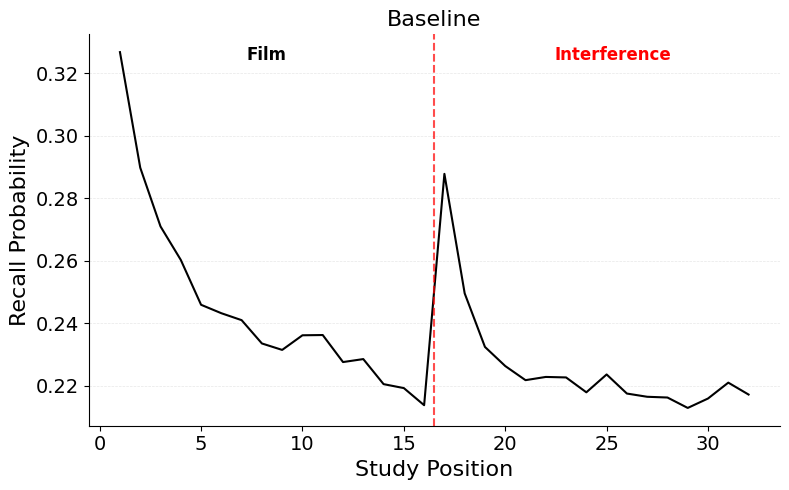

Film items recalled: 3.92 [3.69, 4.16]


In [7]:
BASELINE_MCF_SCALE = 1.0
DEFAULT_PRESENTED = N_FILM + M_DEFAULT + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)

rngs_2d, rng = sweep_rngs(rng)
baseline_recalls_3d = batched_sweep(
    cached_models, rngs_2d,
    DEFAULT_INTERFERENCE_ITEMS, DEFAULT_FILLER_ITEMS,
    jnp.float32(1.0), jnp.float32(BASELINE_MCF_SCALE),
    jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
)
baseline_recalls = baseline_recalls_3d.reshape(-1, baseline_recalls_3d.shape[-1])
if SHOW_FILLERS_IN_SPC:
    baseline_recalls = remap_recalls(baseline_recalls, M_DEFAULT)
baseline_spc = fixed_pres_spc(baseline_recalls, DEFAULT_PRESENTED)
baseline_stats = film_recalled_stats(baseline_recalls)

fig, ax = plt.subplots(figsize=(8, 5))
plot_interference_spc([baseline_spc], ["Baseline"], N_FILM,
                      color_cycle=["black"], axis=ax)
add_filler_boundary(ax, M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
ax.set_title("Baseline", fontsize=16)
ax.get_legend().remove()
fig.tight_layout()
plt.show()

mu, lo, hi = baseline_stats
print(f"Film items recalled: {mu:.2f} [{lo:.2f}, {hi:.2f}]")

## Calibrating filler count

Without filler events between interference encoding and recall, interference items benefit from a strong recency advantage — they were the most recently encoded items, so their context states are maximally similar to the retrieval probe at test onset. Filler items simulate everyday events that occur between the interference task and the recall test. By encoding additional items after the interference phase, fillers push interference items out of the recency window, forcing any remaining interference to arise from contextual overlap with the film region rather than temporal proximity.

This sweep varies the number of filler items from 0 to 32 to determine how many are needed. Filler encoding uses the subject's fitted parameters at their default scale.

In [8]:
filler_count_values = np.arange(0, N_FILLER_MAX + 1, 4)
print(f"Filler count sweep values: {filler_count_values}")

FILLER_PRESENTED_WITH = N_FILM + M_DEFAULT + N_FILLER_MAX
FILLER_PRESENTED_WITHOUT = N_FILM + M_DEFAULT

sweep_filler_spcs_with = []
sweep_filler_spcs_without = []
sweep_filler_stats = []

for n_fill in filler_count_values:
    rngs_2d, rng = sweep_rngs(rng)
    filler_items = make_filler_items(int(n_fill))
    recalls_3d = batched_sweep(
        cached_models, rngs_2d,
        DEFAULT_INTERFERENCE_ITEMS, filler_items,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    sweep_filler_spcs_without.append(fixed_pres_spc(recalls, FILLER_PRESENTED_WITHOUT))
    recalls_remapped = remap_recalls(recalls, M_DEFAULT)
    sweep_filler_spcs_with.append(fixed_pres_spc(recalls_remapped, FILLER_PRESENTED_WITH))
    sweep_filler_stats.append(film_recalled_stats(recalls))

print("Filler count sweep done")

Filler count sweep values: [ 0  4  8 12 16 20 24 28 32]


Filler count sweep done


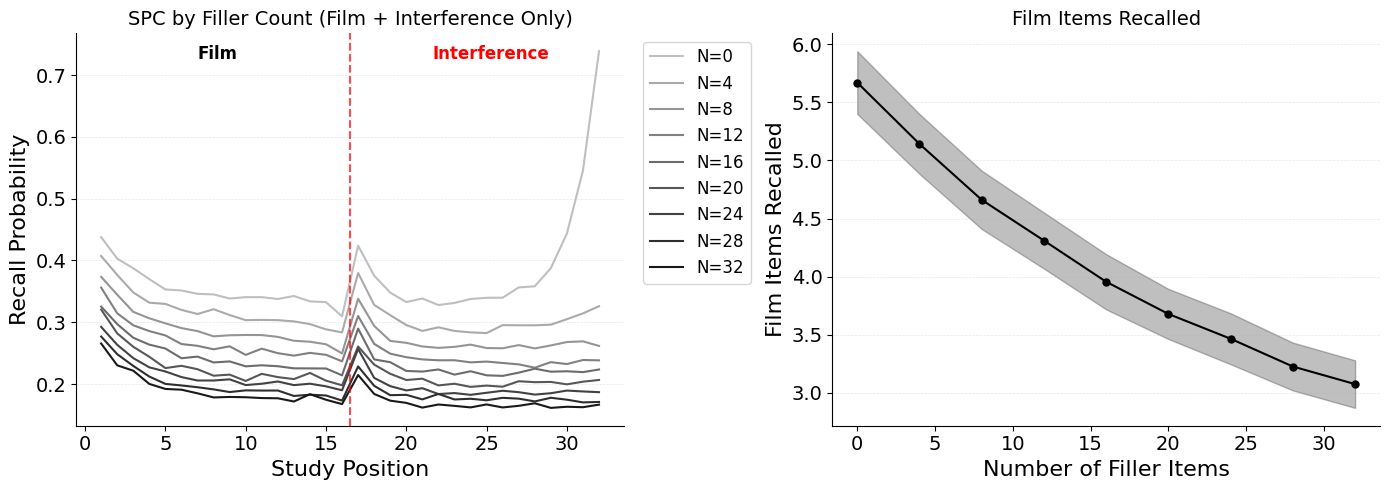

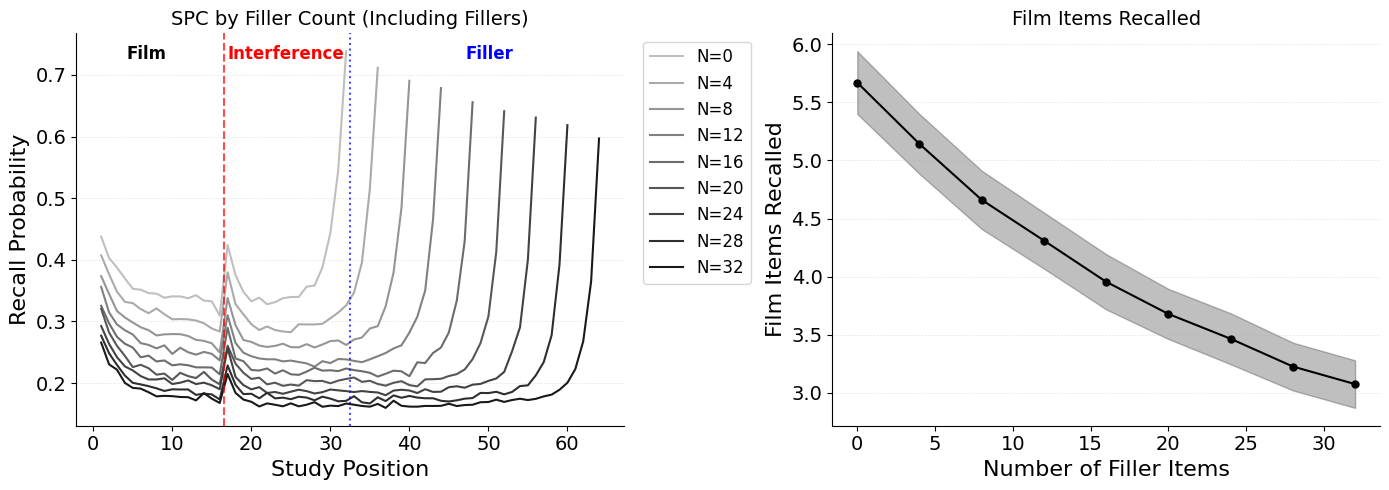

In [9]:
labels = [f"N={n}" for n in filler_count_values]
means, ci_lo, ci_hi = zip(*sweep_filler_stats)

# --- Plot 1: without fillers in SPC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_filler_spcs_without, labels, N_FILM, axis=axes[0])
axes[0].set_title("SPC by Filler Count (Film + Interference Only)", fontsize=14)

plot_summary_dv(
    filler_count_values, means, ci_lo, ci_hi,
    xlabel="Number of Filler Items", axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

# --- Plot 2: with fillers in SPC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_presented_filler = [N_FILM + M_DEFAULT + int(n) for n in filler_count_values]
plot_interference_spc(sweep_filler_spcs_with, labels, N_FILM,
                      n_presented=n_presented_filler, axis=axes[0])
filler_start = N_FILM + M_DEFAULT + 0.5
axes[0].axvline(x=filler_start, color="blue", linewidth=1.5, linestyle=":", alpha=0.7)
for txt in list(axes[0].texts):
    txt.remove()
film_x = (N_FILM + 0.5) / FILLER_PRESENTED_WITH / 2
interf_x = ((N_FILM + 0.5) / FILLER_PRESENTED_WITH + filler_start / FILLER_PRESENTED_WITH) / 2
filler_x = (filler_start / FILLER_PRESENTED_WITH + 1) / 2
axes[0].text(film_x, 0.97, "Film", ha="center", va="top",
             fontsize=12, fontweight="bold", transform=axes[0].transAxes)
axes[0].text(interf_x, 0.97, "Interference", ha="center", va="top",
             fontsize=12, fontweight="bold", color="red", transform=axes[0].transAxes)
axes[0].text(filler_x, 0.97, "Filler", ha="center", va="top",
             fontsize=12, fontweight="bold", color="blue", transform=axes[0].transAxes)
axes[0].set_title("SPC by Filler Count (Including Fillers)", fontsize=14)

plot_summary_dv(
    filler_count_values, means, ci_lo, ci_hi,
    xlabel="Number of Filler Items", axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

## Sweeping interference MCF learning rate

The first encoding-phase intensifier is encoding strength in the context-to-item association matrix (M\_CF). During film encoding, the MCF learning rate follows the fitted primacy gradient — high at position 1, decaying toward 1.0 by position 16. During the interference phase, each competitor's MCF learning rate is a scale factor times what the primacy gradient would assign at that position. At scale = 1.0, interference items are encoded exactly as if they were additional study items; at scale = 0, they receive no M\_CF encoding; at scale > 1, they are encoded more strongly than normal.

The sweep ranges from 0 to 4.0 in 10 steps. Each subject uses their own fitted `encoding_drift_rate` during the interference phase, keeping context proximity constant across the sweep.

In [10]:
mcf_scale_values = np.linspace(0, 3, 10)
print(f"MCF scale sweep values: {mcf_scale_values.round(2)}")

sweep1_spcs = []
sweep1_stats = []

for scale_val in mcf_scale_values:
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_models, rngs_2d,
        DEFAULT_INTERFERENCE_ITEMS, DEFAULT_FILLER_ITEMS,
        jnp.float32(1.0), jnp.float32(scale_val),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    if SHOW_FILLERS_IN_SPC:
        recalls = remap_recalls(recalls, M_DEFAULT)
    sweep1_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep1_stats.append(film_recalled_stats(recalls))

print("Sweep 1 done")

MCF scale sweep values: [0.   0.33 0.67 1.   1.33 1.67 2.   2.33 2.67 3.  ]


Sweep 1 done


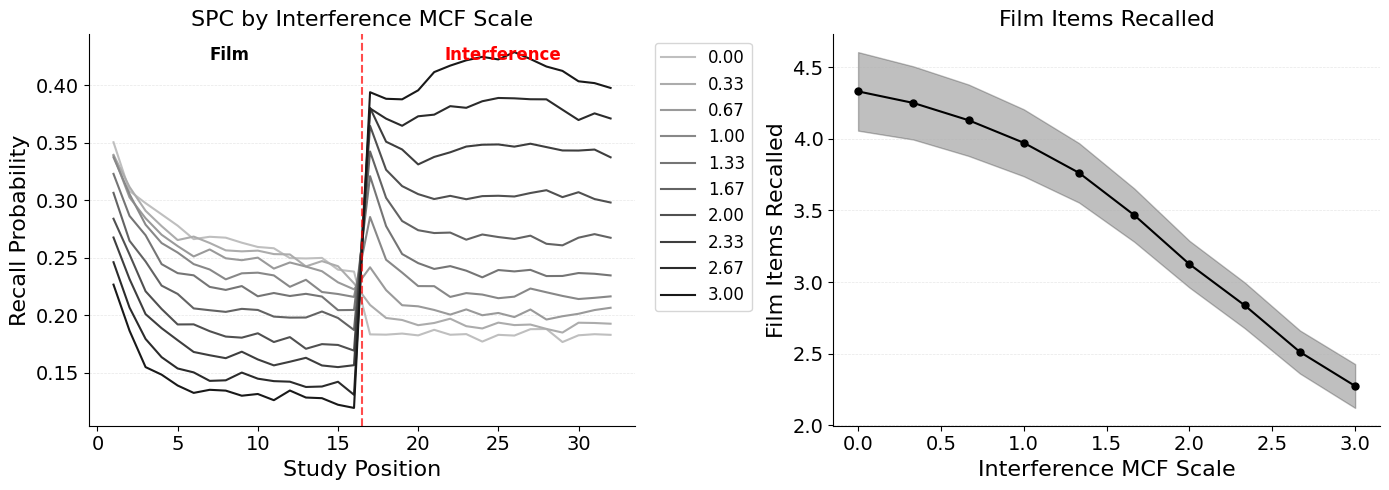

In [11]:
labels = [f"{v:.2f}" for v in mcf_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep1_spcs, labels, N_FILM, axis=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Interference MCF Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep1_stats)
plot_summary_dv(
    mcf_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Interference MCF Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

The left panel shows how the serial position curve changes as MCF scale increases. At scale = 0, competitors receive no encoding and are never recalled — the SPC matches the film-only baseline. As the scale grows, interference items accumulate retrieval support and the Luce choice rule redistributes recall probability away from film items, particularly those at late study positions whose recency advantage is directly contested.

The right panel condenses this into a single dependent variable: mean film items recalled with 95% CI. The monotonic decrease confirms that stronger M\_CF encoding of competitors produces more interference — the first of our three intensifiers.

## Sweeping interference encoding drift rate

The second intensifier is context proximity between film items and competitors. The `encoding_drift_rate` parameter controls how much temporal context updates when each item is encoded. During the film phase, this is the subject's fitted value. During interference, we scale it by a factor: at scale = 1.0 context drifts at the same rate as during film encoding; at scale < 1.0 drift is slower (competitors stay closer to film context); at scale > 1.0 drift is faster (competitors are pushed further away). The product is clipped to [0, 1].

Low drift during interference keeps competitors' context representations close to the end-of-film context state. High drift pushes competitors into a distant region of context space where they are poor matches for the retrieval probe.

We expect a dose-response curve: low scales produce maximal interference, and increasing scale progressively reduces it, approaching a ceiling where competitors are so contextually distant they barely compete. We fix the MCF scale at 1.0 and sweep drift scale from 0.2 to 1.8.

In [24]:
drift_scale_values = np.linspace(0.2, 1.6, 10)
print(f"Drift scale sweep values: {drift_scale_values.round(2)}")

sweep2_spcs = []
sweep2_stats = []

for ds in drift_scale_values:
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_models, rngs_2d,
        DEFAULT_INTERFERENCE_ITEMS, DEFAULT_FILLER_ITEMS,
        jnp.float32(ds), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    if SHOW_FILLERS_IN_SPC:
        recalls = remap_recalls(recalls, M_DEFAULT)
    sweep2_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep2_stats.append(film_recalled_stats(recalls))

print("Sweep 2 done")

Drift scale sweep values: [0.2  0.36 0.51 0.67 0.82 0.98 1.13 1.29 1.44 1.6 ]
Sweep 2 done


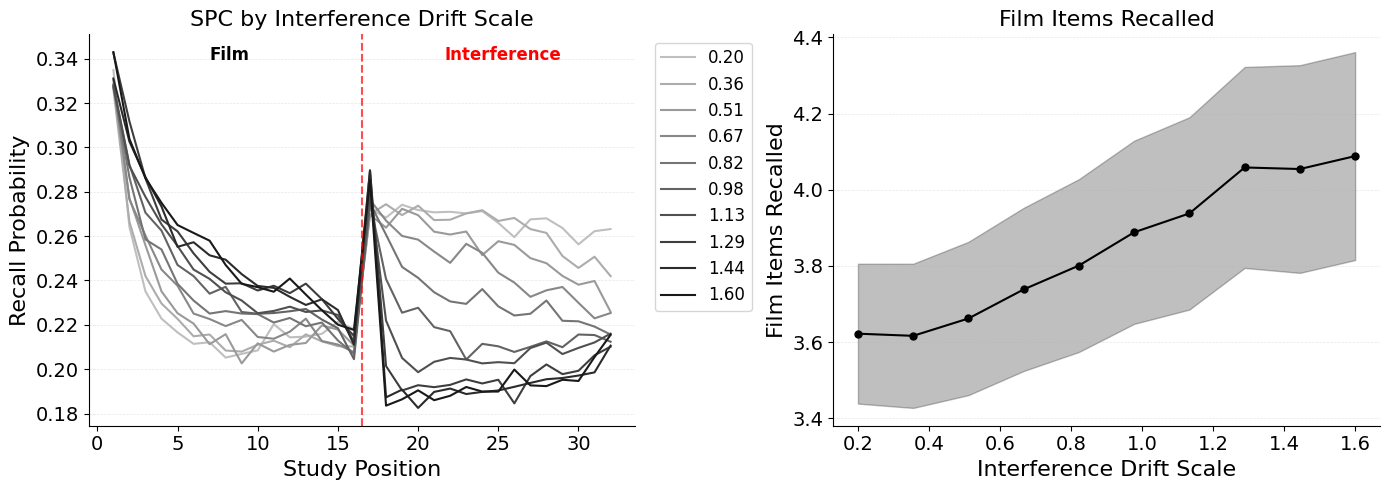

In [25]:
labels = [f"{v:.2f}" for v in drift_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep2_spcs, labels, N_FILM, axis=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Interference Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep2_stats)
plot_summary_dv(
    drift_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Interference Drift Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

Low drift scales produce the most interference: competitors encoded in film-like context compete strongly at retrieval, suppressing film recall. As the scale increases, competitors are pushed into increasingly distant context states, reducing their activation during retrieval and allowing more film items to be recalled. The curve approaches a ceiling at high scales — beyond a certain point, further increases produce negligible additional relief because the competitors are already contextually irrelevant.

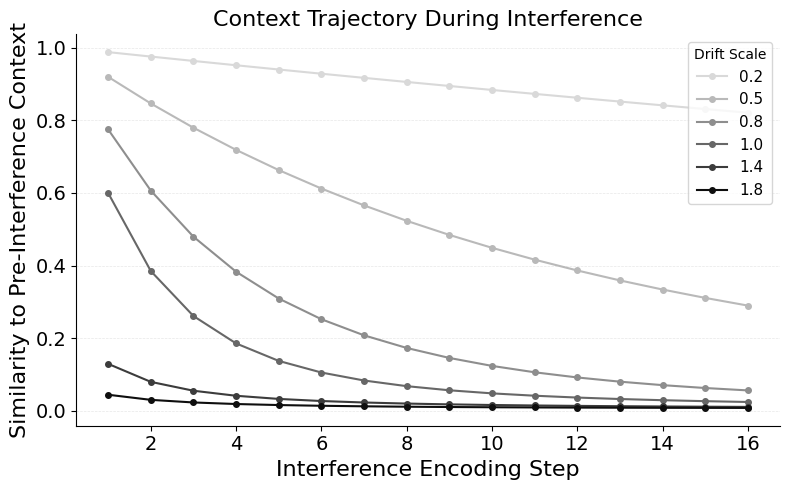

In [26]:
def track_interference_context(
    cached_model, interference_items, drift_scale, mcf_scale
):
    """Similarity to pre-interference context after each encoding step."""
    reference = cached_model.context.state
    original_drift = cached_model.encoding_drift_rate
    original_mcf_lr = cached_model._mcf_learning_rate

    interference_drift = jnp.clip(drift_scale * original_drift, 0.0, 1.0)
    model = cached_model.replace(
        encoding_drift_rate=interference_drift,
        _mcf_learning_rate=mcf_scale * original_mcf_lr,
    )

    def step(m, i):
        m = m.experience(interference_items[i])
        sim = jnp.dot(
            m.context.state / jnp.linalg.norm(m.context.state),
            reference / jnp.linalg.norm(reference),
        )
        return m, sim

    _, trajectory = lax.scan(step, model, jnp.arange(interference_items.shape[0]))
    return trajectory


_batched_trajectory = jit(
    vmap(track_interference_context, in_axes=(0, None, None, None))
)

# Track context trajectory at several drift scale values
traj_drift_values = np.array([0.2, 0.5, 0.8, 1.0, 1.4, 1.8])
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(traj_drift_values)))

for ds, color in zip(traj_drift_values, colors):
    traj = _batched_trajectory(
        cached_models, DEFAULT_INTERFERENCE_ITEMS,
        jnp.float32(ds), jnp.float32(1.0),
    )
    # Only plot the first M_DEFAULT steps (rest are zero-padded no-ops)
    mean_traj = np.asarray(jnp.mean(traj[:, :M_DEFAULT], axis=0))
    ax.plot(np.arange(1, M_DEFAULT + 1), mean_traj, "o-", color=color,
            label=f"{ds:.1f}", markersize=4, linewidth=1.5)

ax.set_xlabel("Interference Encoding Step", fontsize=16)
ax.set_ylabel("Similarity to Pre-Interference Context", fontsize=16)
ax.set_title("Context Trajectory During Interference", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Drift Scale", loc="upper right", fontsize=11)
fig.tight_layout()
plt.show()

## Sweeping competitor count

The third intensifier is the sheer number of competitors. With drift and MCF scales both fixed at 1.0 (interference items encoded identically to additional study items), adding more competitors should reduce film recall — but with diminishing returns, because later competitors drift further from film context and therefore compete less effectively.

In [15]:
m_values = np.arange(10, 33, 2, dtype=int)
print(f"Competitor count sweep values: {m_values}")

COMP_PRESENTED = N_FILM + M_MAX + (N_FILLER_DEFAULT if SHOW_FILLERS_IN_SPC else 0)

sweep3_spcs = []
sweep3_stats = []

for m in m_values:
    rngs_2d, rng = sweep_rngs(rng)
    interf_items = make_interference_items(int(m))
    recalls_3d = batched_sweep(
        cached_models, rngs_2d,
        interf_items, DEFAULT_FILLER_ITEMS,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    sweep3_spcs.append(fixed_pres_spc(recalls, COMP_PRESENTED))
    sweep3_stats.append(film_recalled_stats(recalls))

print("Sweep 3 done")

Competitor count sweep values: [10 12 14 16 18 20 22 24 26 28 30 32]


Sweep 3 done


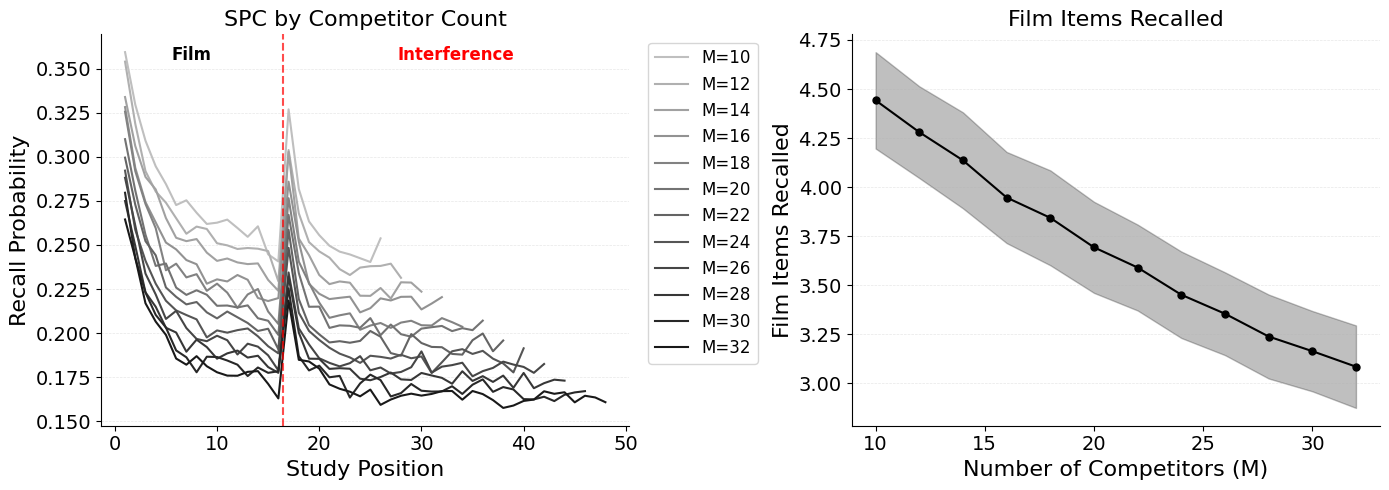

In [16]:
labels = [f"M={m}" for m in m_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_presented_comp = [N_FILM + int(m) for m in m_values]
plot_interference_spc(sweep3_spcs, labels, N_FILM,
                      n_presented=n_presented_comp, axis=axes[0])
add_filler_boundary(axes[0], M_MAX, N_FILLER_DEFAULT, COMP_PRESENTED)
axes[0].set_title("SPC by Competitor Count", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep3_stats)
plot_summary_dv(
    m_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Competitors (M)",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

More competitors produce more interference, but with diminishing returns as predicted. The first few competitors — those encoded in context most similar to the film items — have the strongest suppressive effect. Later competitors are encoded after more contextual drift and contribute progressively less interference. The SPC shows the interference effect concentrated at late film positions: recency is eroded first, while primacy is relatively protected by the strong M\_CF encoding at early positions.

This diminishing-returns pattern has an important empirical implication: the *timing* of interference (context proximity) matters more than the *amount* (raw count). A small number of competitors encoded in highly similar context can produce more interference than many competitors encoded after substantial drift.

## Pre-interference context state: delay and reminder

The three sweeps above establish what makes interference *stronger*. A separate question is what determines *which film items* are most vulnerable. The answer lies in the context state at the moment competitors are encoded — this determines which film items share the most contextual overlap with the interference phase.

Two parameters control this pre-interference context state:

- **`reminder_start_drift_scale`** — a scale over each subject's fitted `start_drift_rate`, controlling how much context drifts toward start-of-list after film encoding. This simulates the passage of time between original viewing and the interference task. At low scales, context stays near end-of-film; at high scales, it drifts toward start-of-list (simulating a long delay).

- **`reminder_drift_scale`** — a scale over each subject's fitted `encoding_drift_rate`, controlling how strongly the reminder reinstates film context. At low scales, the reminder has little effect; at high scales, context is driven back through the film sequence, arriving at a state resembling end-of-film encoding.

Together, these parameters give continuous control over the pre-interference context landscape, subsuming the discrete conditions explored in the original delayed-interference design (Sim 5).

### Sweeping start-of-list drift scale

How much does the delay between film viewing and interference matter? At low scales, context stays near end-of-film — competitors are encoded in film-adjacent context regardless of the reminder. At high scales, context drifts toward start-of-list, pushing competitors into contextually distant territory. The reminder drift scale is held at its default throughout this sweep.

In [17]:
start_drift_scale_values = np.linspace(0.01, 4.0, 10)
print(f"Start-of-list drift scale sweep values: {start_drift_scale_values.round(2)}")

sweep_start_spcs = []
sweep_start_stats = []

for sds in start_drift_scale_values:
    cached_sds = prepare_all_subjects(
        jnp.arange(n_subjects), params, FILM_ITEMS,
        jnp.float32(sds), jnp.float32(DEFAULT_REMINDER_DRIFT_SCALE),
    )
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_sds, rngs_2d,
        DEFAULT_INTERFERENCE_ITEMS, DEFAULT_FILLER_ITEMS,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    if SHOW_FILLERS_IN_SPC:
        recalls = remap_recalls(recalls, M_DEFAULT)
    sweep_start_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep_start_stats.append(film_recalled_stats(recalls))

print("Start-of-list drift scale sweep done")

Start-of-list drift scale sweep values: [0.01 0.45 0.9  1.34 1.78 2.23 2.67 3.11 3.56 4.  ]


Start-of-list drift scale sweep done


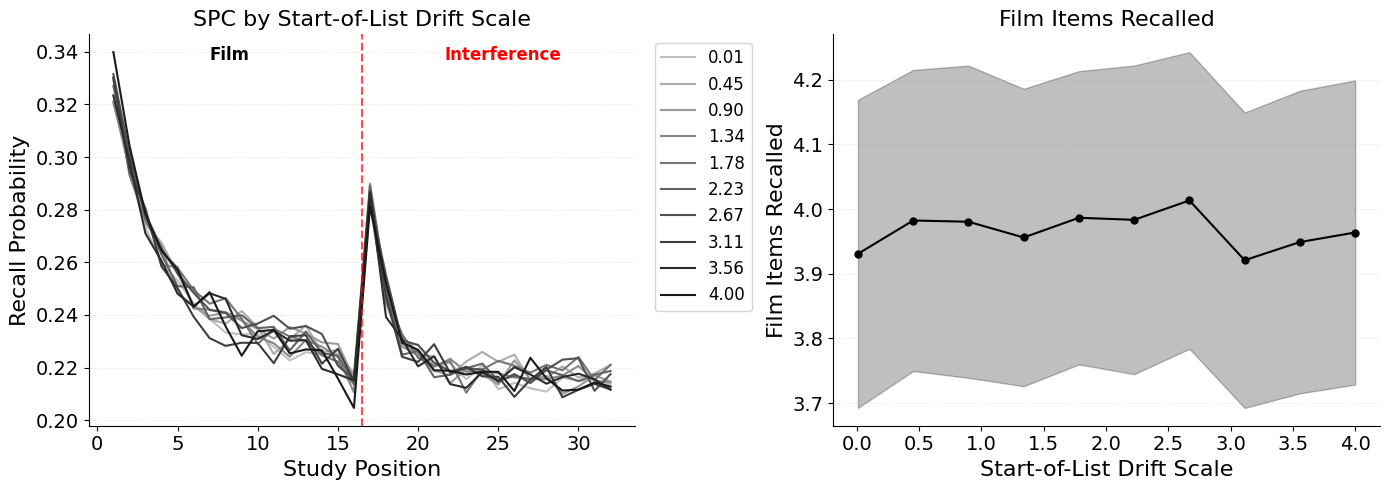

In [18]:
labels = [f"{v:.2f}" for v in start_drift_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_start_spcs, labels, N_FILM, axis=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Start-of-List Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep_start_stats)
plot_summary_dv(
    start_drift_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Start-of-List Drift Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

### Sweeping reminder drift scale

With the delay drift scale held at its default, this sweep varies how strongly the reminder reinstates film context. At low scales, context barely moves from the post-delay state. At high scales, context drifts rapidly through the film sequence, arriving at a state dominated by the last few film items. Because interference items are subsequently encoded in this context, the reminder drift scale controls how much contextual overlap exists between film and interference items.

The start-of-list drift scale is held at its default throughout this sweep.

In [19]:
reminder_scale_values = np.linspace(0.01, 1.8, 10)
print(f"Reminder drift scale sweep values: {reminder_scale_values.round(3)}")

sweep_rem_spcs = []
sweep_rem_stats = []

for rs in reminder_scale_values:
    cached_rs = prepare_all_subjects(
        jnp.arange(n_subjects), params, FILM_ITEMS,
        jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE), jnp.float32(rs),
    )
    rngs_2d, rng = sweep_rngs(rng)
    recalls_3d = batched_sweep(
        cached_rs, rngs_2d,
        DEFAULT_INTERFERENCE_ITEMS, DEFAULT_FILLER_ITEMS,
        jnp.float32(1.0), jnp.float32(1.0),
        jnp.float32(DEFAULT_FILLER_DRIFT_SCALE), jnp.float32(DEFAULT_FILLER_MCF_SCALE),
    )
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    if SHOW_FILLERS_IN_SPC:
        recalls = remap_recalls(recalls, M_DEFAULT)
    sweep_rem_spcs.append(fixed_pres_spc(recalls, DEFAULT_PRESENTED))
    sweep_rem_stats.append(film_recalled_stats(recalls))

print("Reminder sweep done")

Reminder drift scale sweep values: [0.01  0.209 0.408 0.607 0.806 1.004 1.203 1.402 1.601 1.8  ]


Reminder sweep done


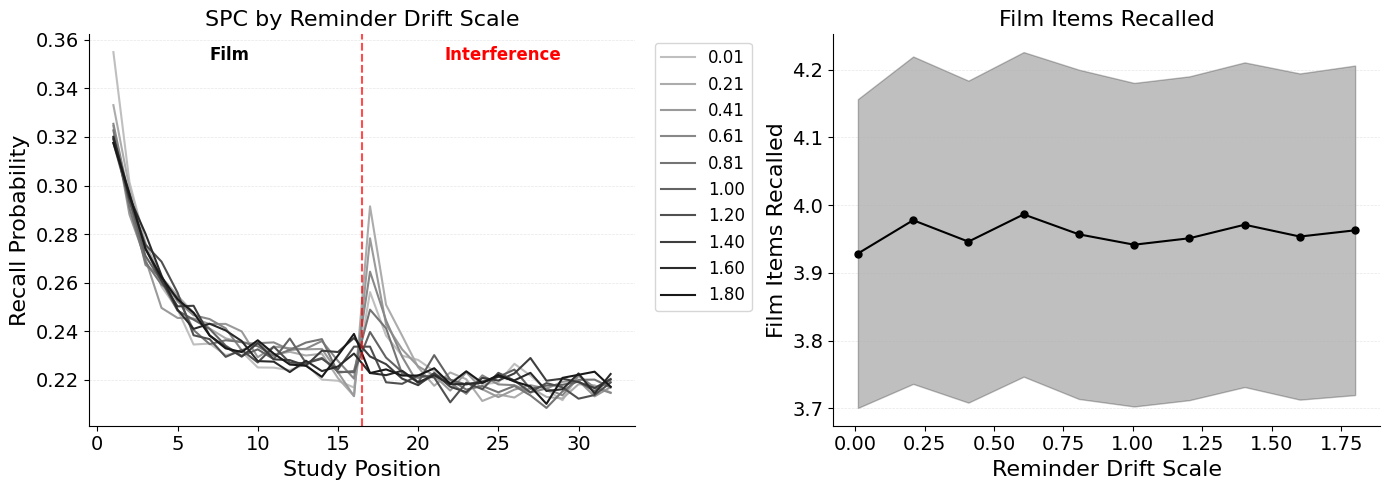

In [20]:
labels = [f"{v:.2f}" for v in reminder_scale_values]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(sweep_rem_spcs, labels, N_FILM, axis=axes[0])
add_filler_boundary(axes[0], M_DEFAULT, N_FILLER_DEFAULT, DEFAULT_PRESENTED)
axes[0].set_title("SPC by Reminder Drift Scale", fontsize=16)

means, ci_lo, ci_hi = zip(*sweep_rem_stats)
plot_summary_dv(
    reminder_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Reminder Drift Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16)
if FILM_RECALLED_YLIM is not None:
    axes[1].set_ylim(*FILM_RECALLED_YLIM)

plt.tight_layout()
plt.show()

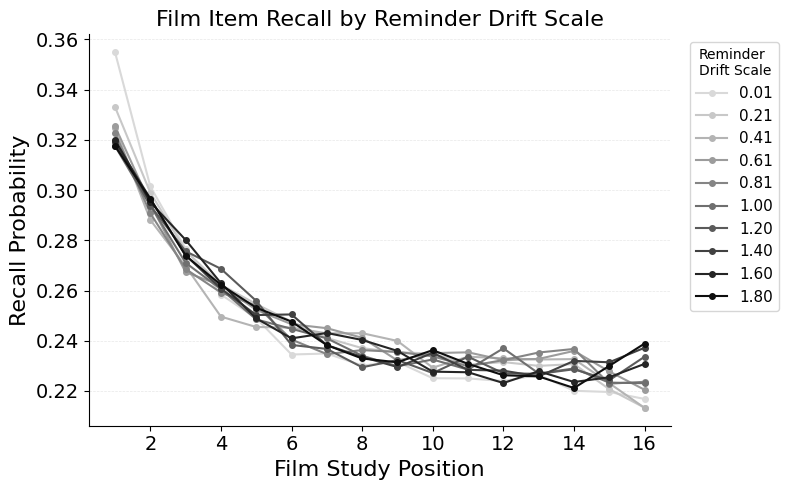

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(1, N_FILM + 1)
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(reminder_scale_values)))

for spc, rs, color in zip(sweep_rem_spcs, reminder_scale_values, colors):
    ax.plot(positions, np.asarray(spc)[:N_FILM], "o-", color=color,
            label=f"{rs:.2f}", markersize=4, linewidth=1.5)

ax.set_xlabel("Film Study Position", fontsize=16)
ax.set_ylabel("Recall Probability", fontsize=16)
ax.set_title("Film Item Recall by Reminder Drift Scale", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Reminder\nDrift Scale", loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=11)
fig.tight_layout()
plt.show()

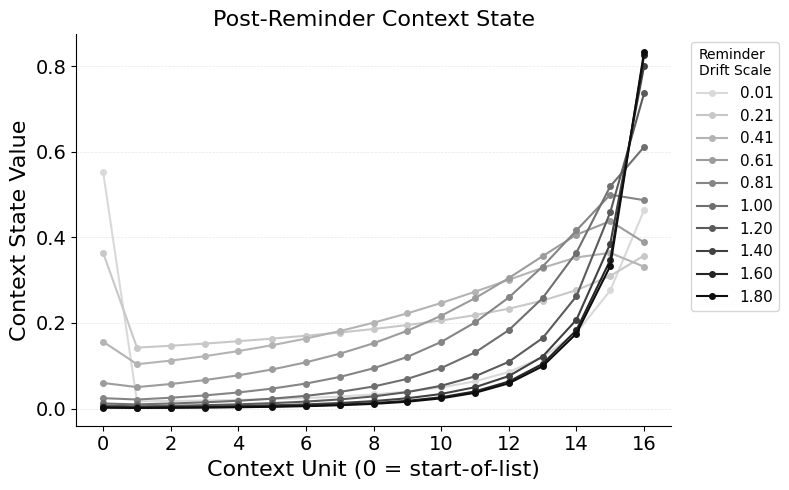

In [22]:
def get_post_reminder_context(subject_idx, params, film_items,
                              reminder_start_drift_scale, reminder_drift_scale):
    """Context state values at film-item units after reminder phase."""
    subject_params = tree_map(lambda p: p[subject_idx], params)
    model = CMR(
        LIST_LENGTH,
        subject_params,
        mfc_create_fn=init_mfc,
        mcf_create_fn=init_mcf,
        context_create_fn=init_context,
        termination_policy_create_fn=PositionalTermination,
    )
    original_drift = model.encoding_drift_rate

    # film phase
    model = lax.fori_loop(
        0, film_items.size, lambda i, m: m.experience(film_items[i]), model
    )

    # delay: drift toward start-of-list context
    delay_drift = jnp.clip(
        reminder_start_drift_scale * model.start_drift_rate, 0.0, 1.0
    )
    model = model.replace(
        context=model.context.integrate(model.context.initial_state, delay_drift)
    )

    # reminder
    reminder_drift = jnp.clip(reminder_drift_scale * original_drift, 0.0, 1.0)

    def reminder_step(i, m):
        item = m.items[film_items[i] - 1]
        context_input = m.mfc.probe(item)
        new_context = m.context.integrate(context_input, reminder_drift)
        return m.replace(context=new_context)

    model = lax.fori_loop(0, film_items.size, reminder_step, model)

    # return context units for film items (indices 1..N_FILM) and start-of-list (index 0)
    return model.context.state[:N_FILM + 1]


_batched_context = jit(
    vmap(get_post_reminder_context, in_axes=(0, None, None, None, None))
)
sub_indices = jnp.arange(n_subjects)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.colormaps["Greys"](np.linspace(0.25, 0.95, len(reminder_scale_values)))

for rs, color in zip(reminder_scale_values, colors):
    ctx = _batched_context(
        sub_indices, params, FILM_ITEMS,
        jnp.float32(DEFAULT_REMINDER_START_DRIFT_SCALE), jnp.float32(rs),
    )
    mean_ctx = np.asarray(jnp.mean(ctx, axis=0))
    # index 0 = start-of-list, indices 1..N_FILM = film items
    positions = np.arange(0, N_FILM + 1)
    ax.plot(positions, mean_ctx, "o-", color=color, label=f"{rs:.2f}",
            markersize=4, linewidth=1.5)

ax.set_xlabel("Context Unit (0 = start-of-list)", fontsize=16)
ax.set_ylabel("Context State Value", fontsize=16)
ax.set_title("Post-Reminder Context State", fontsize=16)
ax.tick_params(labelsize=14)
for loc in ("top", "right"):
    ax.spines[loc].set_visible(False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(title="Reminder\nDrift Scale", loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=11)
fig.tight_layout()
plt.show()

### Context state summary

The film-item SPC reveals what the reminder drift scale does to context before interference begins. At low scales, context stays near the post-delay state — recall is concentrated at the positions most activated by that state. At high scales, context drifts through the full film sequence and arrives at a state resembling end-of-film context, producing a recency-weighted recall profile across film positions.

Together, the delay drift scale and reminder drift scale give continuous control over pre-interference context state. The delay drifts context away from the film region, reducing interference from contextual overlap — but competitors still interfere via their M\_CF associations. The reminder drives context back toward the film region, restoring contextual overlap and increasing the vulnerability of late-film items. The total number of film items recalled is relatively stable across the reminder sweep: the reminder redistributes *which* film items are recalled but has limited effect on *how many*. This confirms that reminders modulate interference targeting, not interference intensity.

This has implications for the delayed-interference paradigm: delayed interference does not require a reconsolidation window. Instead, the reminder reinstates context overlap, creating the conditions for effective competition between film and interference items.

## Summary and parameters for subsequent simulations

Three manipulations intensify interference from competing events, each operating through a distinct mechanism in the retrieved-context framework:

1. **MCF encoding strength** increases retrieval support for competitors, redistributing probability mass away from film items under the Luce choice rule. The effect is monotonic: stronger encoding produces more competition.

2. **Context proximity** (drift scale) controls how much context drifts during the interference phase. Low scales keep competitors in film-adjacent context; high scales push them into contextually distant states. The effect follows a dose-response curve with a ceiling.

3. **Competitor count** adds more entries into the association matrices, but with diminishing returns: later competitors accumulate more contextual drift and therefore compete less effectively. The timing of interference matters more than the raw amount.

A separate dimension — pre-interference context state — controls *which* film items are most vulnerable. The delay drift scale (`reminder_start_drift_scale`) and reminder drift scale (`reminder_drift_scale`) jointly parameterize this. The delay drifts context away from the film region; the reminder reinstates it. Total film recalled is relatively stable across the reminder sweep, but the pattern shifts: reminders redirect interference toward late-film items rather than early ones. This means delayed interference does not require a reconsolidation window — the reminder creates the context overlap needed for effective competition, absorbing the mechanism originally planned as Sim 5.

**Postdictions**: More engaging interference tasks produce stronger effects (MCF encoding); simply increasing task duration shows diminishing returns (competitor count). These patterns map to empirical findings (Holmes et al. 2009; James et al. 2015).

**Predictions**: Interference is primarily driven by MCF encoding strength and context proximity, not count alone. Sequential encoding naturally produces a recency gradient — late-film items are disproportionately suppressed because they share the most temporal context with competitors.

In [23]:
print("Default parameters (non-swept variables):")
print(f"  shared_support scale:         {FITTED_PARAM_SCALES['shared_support']}")
print("  Interference MCF scale:       1.0")
print("  Interference drift scale:     1.0")
print(f"  Reminder start drift scale:   {DEFAULT_REMINDER_START_DRIFT_SCALE}")
print(f"  Reminder drift scale:         {DEFAULT_REMINDER_DRIFT_SCALE}")
print("  Filler drift scale:           1.0")
print("  Filler MCF scale:             1.0")
print(f"  Competitor count (M):         {M_DEFAULT}")
print(f"  Filler count (default):       {N_FILLER_DEFAULT}")
print(f"  Max fillers (sweep):          {N_FILLER_MAX}")
print(f"  Max competitors (sweep):      {M_MAX}")
print(f"  Subjects:                     {n_subjects}")
print(f"  Replications per sweep:       {EXPERIMENT_COUNT}")

Default parameters (non-swept variables):
  shared_support scale:         1.0
  Interference MCF scale:       1.0
  Interference drift scale:     1.0
  Reminder start drift scale:   4.0
  Reminder drift scale:         0.3
  Filler drift scale:           1.0
  Filler MCF scale:             1.0
  Competitor count (M):         16
  Filler count (default):       16
  Max fillers (sweep):          32
  Max competitors (sweep):      32
  Subjects:                     126
  Replications per sweep:       100
